#Neural Networks

# Import Data/Preprocessing

The data we are using is about spam classification. The data comes from Kaggle and contains two columns: one saying whether the message is spam or ham, and the message itself. Before doing any modeling, we will process the text data borrowing some of the code from our sentiment analysis lab we had before spring break.

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "spam.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "abdallahwagih/spam-emails",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_165/380521069.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'spam-emails' dataset.
First 5 records:   Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


### What is a Perceptron?

A perceptron is the simplest form of a neural network, capable of performing binary classification. It takes multiple binary inputs and produces a single binary output. The core idea is inspired by how a biological neuron works: it receives electrical signals, processes them, and fires an output signal if the accumulated input reaches a certain threshold.

#### Key Components:
- **Inputs (x):** These are the features of the data point. Each input has an associated weight.
- **Weights (w):** These represent the strength or importance of each input. A higher weight means the input has a greater impact on the output.
- **Bias (b):** This is an additional constant value that is added to the weighted sum of inputs. It helps the perceptron to activate even when all inputs are zero, or shift the decision boundary.
- **Weighted Sum (z):** This is the sum of the products of inputs and their corresponding weights, plus the bias: $z = \sum (x_i * w_i) + b$.
- **Activation Function (f):** This function determines the output of the perceptron based on the weighted sum. For a simple perceptron, a common activation function is the step function, which outputs 1 if the weighted sum exceeds a threshold (often 0), and 0 otherwise.

#### How it Works:
1.  **Receive Inputs:** The perceptron takes multiple input values.
2.  **Compute Weighted Sum:** It calculates the sum of each input multiplied by its respective weight, and adds the bias.
3.  **Apply Activation Function:** The weighted sum is then passed through an activation function, which produces the final binary output (0 or 1).

In essence, a perceptron can draw a single straight line (a decision boundary) to separate two classes of data points. If the data is linearly separable, a perceptron can learn to classify it correctly.

Let's start by implementing a simple perceptron.

In [ ]:
!pip install gensim contractions -q
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

RANDOM_STATE = 42

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.6 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
def clean_text(text):
    text = contractions.fix(text)                        # Expand contractions
    text = text.lower()                                  # Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)           # Remove URLs
    text = re.sub(r'@\w+', '', text)                     # Remove @mentions
    text = re.sub(r'#', '', text)                        # Remove # symbol (keep word)
    text = re.sub(r'[^\w\s]', '', text)                  # Remove punctuation
    text = re.sub(r'\b\d+\b', '', text)                  # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()             # Remove extra whitespace
    return text

stop_words = set(stopwords.words('english'))
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [ ]:
def preprocess(text):
  # TODO: Write a function to preprocess the text
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    return ' '.join(tokens)

df['processed'] = df['Message'].apply(preprocess)

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(df['processed'])

In [ ]:
import numpy as np

# Create a binary target variable from 'Category'
# Map 'ham' to 0 and 'spam' to 1
df['Category_numeric'] = df['Category'].map({'ham': 0, 'spam': 1})

# Assign features (X) and target (y) for the perceptron
X = X_tfidf.toarray() # Convert sparse matrix to dense array for perceptron
y = df['Category_numeric'].values

print("First 5 records of processed features (X shape) and target (y):")
print("X shape:", X.shape)
print("y:", y[:5])
print(f"Number of samples after cleaning: {len(df)}")

First 5 records of processed features (X shape) and target (y):
X shape: (5572, 1000)
y: [0 0 1 0 0]
Number of samples after cleaning: 5572


Now that our data is prepared, let's define the `Perceptron` class. This class will encapsulate the logic for initializing weights, making predictions, and updating weights during training.

In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iterations=100):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.errors_ = []

    def _step_function(self, x):
        return 1 if x >= 0 else 0

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            errors = 0
            for xi, target in zip(X, y):
                # Calculate weighted sum
                linear_output = np.dot(xi, self.weights) + self.bias
                # Make prediction
                y_predicted = self._step_function(linear_output)

                # Update weights and bias
                update = self.learning_rate * (target - y_predicted)
                self.weights += update * xi
                self.bias += update
                errors += int(update != 0)
            self.errors_.append(errors)
            # Optional: break if no errors (converged)
            if errors == 0 and _ > 0: # Avoid breaking on first iteration if it miraculously gets it right
                print(f"Perceptron converged after {_ + 1} iterations.")
                break

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.array([self._step_function(output) for output in linear_output])

print("Perceptron class defined successfully.")

Perceptron class defined successfully.


With the `Perceptron` class defined, we can now normalize our features, instantiate the perceptron, train it on our prepared data, and evaluate its performance.

Perceptron Accuracy: 0.94


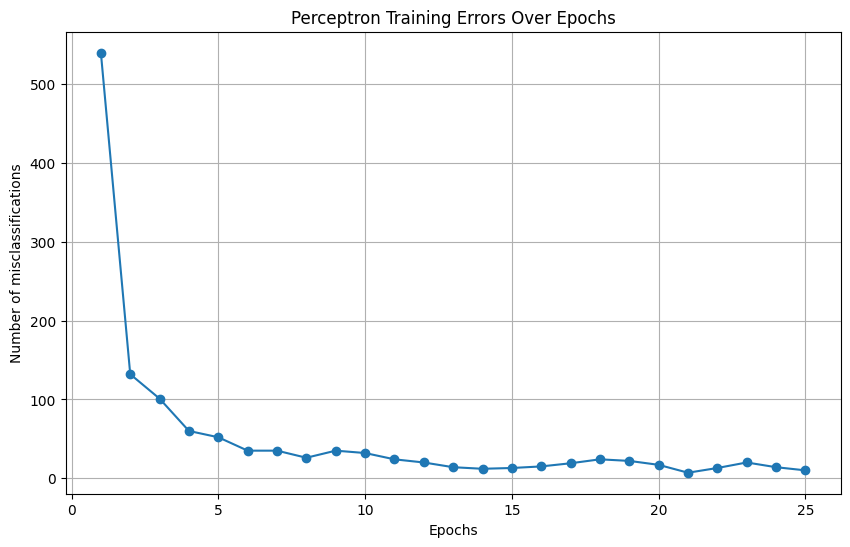

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize and train the perceptron
perceptron = Perceptron(learning_rate=0.01, n_iterations=25)
perceptron.fit(X_train, y_train)

# Make predictions on the test set
y_pred = perceptron.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Perceptron Accuracy: {accuracy:.2f}")

# Plot the errors over iterations
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(perceptron.errors_) + 1), perceptron.errors_, marker='o', linestyle='-')
plt.xlabel('Epochs')
plt.ylabel('Number of misclassifications')
plt.title('Perceptron Training Errors Over Epochs')
plt.grid(True)
plt.show()

## Multi-Layer Perceptron (MLP)

A Multi-Layer Perceptron (MLP) is a class of feedforward artificial neural network. It consists of at least three layers of nodes: an input layer, a hidden layer, and an output layer. Unlike a single perceptron, which can only learn linearly separable patterns, an MLP with one or more hidden layers can learn non-linear relationships in the data. This ability makes MLPs much more powerful and versatile for a wider range of classification and regression tasks.

#### Key Concepts for MLPs:

-   **Hidden Layers:** These are intermediate layers between the input and output layers. Each node (neuron) in a hidden layer processes inputs from the previous layer, applies an activation function, and passes the result to the next layer.
-   **Activation Functions:** While a single perceptron often uses a simple step function, MLPs typically use non-linear activation functions like ReLU (Rectified Linear Unit), sigmoid, or tanh in their hidden layers. Non-linearity is crucial for the network to learn complex patterns. The output layer usually uses a sigmoid activation for binary classification (outputting probabilities) or softmax for multi-class classification.
-   **Weights and Biases:** Similar to a perceptron, each connection between neurons has an associated weight, and each neuron has a bias. These parameters are learned during the training process.
-   **Dropout Layers:** To combat overfitting, especially in deeper networks, Dropout layers are often used. During training, a certain percentage of neurons (and their connections) are randomly ignored or 'dropped out' from each layer. This prevents neurons from co-adapting too much and forces the network to learn more robust features, improving its generalization to unseen data.
-   **Forward Propagation:** This is the process where input data is fed through the network, layer by layer, until an output prediction is generated.
-   **Backpropagation:** This is the core algorithm used to train MLPs. It involves calculating the error between the network's prediction and the actual target, and then propagating this error backward through the network. This error signal is used to adjust the weights and biases in each layer, minimizing the overall error.
-   **Loss Function:** A function that quantifies the difference between the predicted output and the true output (e.g., binary cross-entropy for binary classification).
-   **Optimizer:** An algorithm that adjusts the weights and biases to minimize the loss function (e.g., Adam, SGD).

Let's implement a simple MLP using `tensorflow.keras` to classify our spam messages.

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8785 - loss: 0.3118 - val_accuracy: 0.9436 - val_loss: 0.1460
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9724 - loss: 0.0805 - val_accuracy: 0.9744 - val_loss: 0.1007
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9901 - loss: 0.0317 - val_accuracy: 0.9718 - val_loss: 0.1049
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9946 - loss: 0.0173 - val_accuracy: 0.9718 - val_loss: 0.1105
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9965 - loss: 0.0118 - val_accuracy: 0.9718 - val_loss: 0.1203
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9981 - loss: 0.0073 - val_accuracy: 0.9744 - val_loss: 0.1375
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9994 - loss: 0.0051 - val_accuracy: 0.9705 - val_loss: 0.1484
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9990 - loss: 0.0052 - val_accuracy: 0.9705 - val_loss: 0.1527
Epo

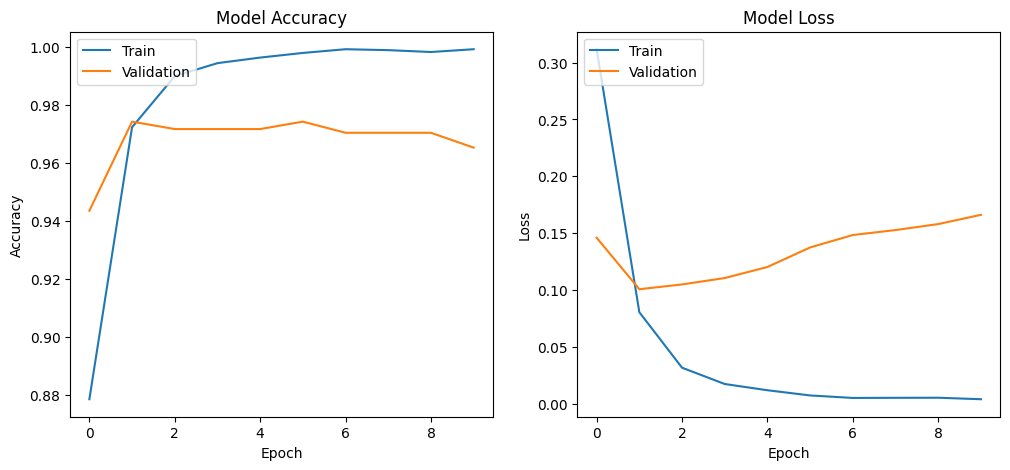

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Split data into training and testing sets
# We'll use the same X and y from the perceptron step
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalize features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the MLP model
# We'll use a Sequential model, which is a linear stack of layers.
model = keras.Sequential([
    # Input layer and first hidden layer
    keras.layers.Dense(units=128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    # Add a Dropout layer to prevent overfitting
    keras.layers.Dropout(0.3), # Dropout 30% of the neurons

    # Second hidden layer
    keras.layers.Dense(units=64, activation='relu'),
    # Add another Dropout layer
    keras.layers.Dropout(0.3),

    # Output layer
    keras.layers.Dense(units=1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nMLP Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

### Interpreting the MLP Training History Plots

These plots provide insights into how the Multi-Layer Perceptron (MLP) model learned over the training epochs.

**Left Plot: Model Accuracy**

*   **Train Accuracy (blue line):** This shows the accuracy of the model on the training data. A high and steadily increasing training accuracy indicates that the model is learning the patterns in the data effectively.
*   **Validation Accuracy (orange line):** This shows the accuracy of the model on the validation data (a portion of the training data set aside for evaluation during training). The validation accuracy is a more realistic measure of how well the model generalizes to unseen data.
*   **Observations:** In this plot, the training accuracy quickly reaches very high levels (near 1.0), while the validation accuracy also starts high and remains relatively stable. If there's a significant and consistent gap where training accuracy is much higher than validation accuracy, it might suggest **overfitting**, meaning the model has learned the training data too well, including its noise, and may not perform as well on new, unseen data.

**Right Plot: Model Loss**

*   **Train Loss (blue line):** This represents the error of the model on the training data. A decreasing trend in training loss indicates that the model is getting better at making predictions on the data it has seen.
*   **Validation Loss (orange line):** This shows the error of the model on the validation data. Like validation accuracy, this is a key indicator of generalization. A decreasing validation loss is good, but if it starts to increase while training loss continues to decrease, it's another strong sign of **overfitting**.
*   **Observations:** Similar to accuracy, the training loss rapidly decreases to a very low value. The validation loss also decreases initially but then slightly increases or fluctuates, suggesting that the model might be starting to overfit slightly, though the overall performance remains strong.

Overall, the MLP achieved a high accuracy on the test set, demonstrating its effectiveness in classifying spam messages.